# **DATA PREPROCESSING**

In [ ]:
#@title Importing Libraries for dataset
import pandas as pd
import numpy as np

In [ ]:
#@title Loading Dataset
path = "/content/sample_data/Students.csv"
df = pd.read_csv(path)

# About Dataset

In [ ]:
#@title Shape of Dataset
print("Shape of the Dataset")
print(f"No of rows: {df.shape[0]}")
print(f"No of columns: {df.shape[1]}")

Shape of the Dataset
No of rows: 3614
No of columns: 16


**Current Size of Dataset** - 3614 X 16

In [ ]:
#@title Columns of Dataset
print("Columns of the Dataset")
df.columns

Columns of the Dataset


Index(['Student_Name', 'College_Name', 'Stream', 'Year_of_Study',
       'AI_Tools_Used', 'Daily_Usage_Hours', 'Use_Cases', 'Trust_in_AI_Tools',
       'Impact_on_Grades', 'Do_Professors_Allow_Use', 'Preferred_AI_Tool',
       'Awareness_Level', 'Willing_to_Pay_for_Access', 'State', 'Device_Used',
       'Internet_Access'],
      dtype='object')

In [ ]:
#@title Overview of Dataset
print("First 5 rows of the Dataset")
df.head()

First 5 rows of the Dataset


,Student_Name,College_Name,Stream,Year_of_Study,AI_Tools_Used,Daily_Usage_Hours,Use_Cases,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,State,Device_Used,Internet_Access
0,Aarav,Indian Institute of Information Technology,Engineering,4,Gemini,0.9,"Assignments, Coding Help",2,2,No,Copilot,9,Yes,Uttar pradesh,Mobile,Poor
1,Vivaan,"Government Ram Bhajan Rai NES College, Jashpur",Commerce,2,ChatGPT,3.4,Learning new topics,3,-3,Yes,Other,6,No,Chhattisgarh,Laptop,Poor
2,Aditya,Dolphin PG Institute of BioMedical & Natural,Science,2,Copilot,3.6,"MCQ Practice, Projects",5,0,No,Gemini,1,No,Uttarakhand,Tablet,Poor
3,Vihaan,Shaheed Rajguru College of Applied Sciences for,Arts,2,Copilot,2.9,Content Writing,5,2,Yes,Gemini,5,No,Delhi ncr,Laptop,High
4,Arjun,Roorkee College of Engineering,Science,1,Gemini,0.9,"Doubt Solving, Resume Writing",1,3,Yes,Other,8,Yes,Uttarakhand,Laptop,Medium


In [ ]:
#@title Column Data type
df.dtypes

,0
Student_Name,object
College_Name,object
Stream,object
Year_of_Study,int64
AI_Tools_Used,object
Daily_Usage_Hours,float64
Use_Cases,object
Trust_in_AI_Tools,int64
Impact_on_Grades,int64
Do_Professors_Allow_Use,object


In [ ]:
#@title No of Null Values in each column
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / df.shape[0]) * 100

null_info_df = pd.DataFrame({
    'Column_name': null_counts.index,
    'No of Null Values': null_counts.values,
    '% of column': null_percentages.values
})

print("Null Values Information:")
display(null_info_df)

Null Values Information:


,Column_name,No of Null Values,% of column
0,Student_Name,0,0.000000
1,College_Name,0,0.000000
2,Stream,0,0.000000
3,Year_of_Study,0,0.000000
4,AI_Tools_Used,0,0.000000
5,Daily_Usage_Hours,0,0.000000
6,Use_Cases,0,0.000000
7,Trust_in_AI_Tools,0,0.000000
8,Impact_on_Grades,0,0.000000
9,Do_Professors_Allow_Use,0,0.000000


In [ ]:
#@title No of Unique Values in each column
print("No of Unique Values in Each column")
unique_values = df.nunique()
unique_values_df = pd.DataFrame({
    'Column_name': unique_values.index,
    'No of Unique Values': unique_values})
display(unique_values_df)

No of Unique Values in Each column


,Column_name,No of Unique Values
Student_Name,Student_Name,40
College_Name,College_Name,1246
Stream,Stream,10
Year_of_Study,Year_of_Study,4
AI_Tools_Used,AI_Tools_Used,9
Daily_Usage_Hours,Daily_Usage_Hours,46
Use_Cases,Use_Cases,333
Trust_in_AI_Tools,Trust_in_AI_Tools,5
Impact_on_Grades,Impact_on_Grades,11
Do_Professors_Allow_Use,Do_Professors_Allow_Use,2


In [ ]:
#@title Unique Values in each column
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Unique values in column '{column}':")
    print(unique_values)
    print()

Unique values in column 'Student_Name':
['Aarav' 'Vivaan' 'Aditya' 'Vihaan' 'Arjun' 'Sai' 'Reyansh' 'Ayaan'
 'Krishna' 'Ishaan' 'Rudra' 'Dhruv' 'Kabir' 'Atharv' 'Om' 'Anaya' 'Siya'
 'Diya' 'Myra' 'Aadhya' 'Riya' 'Pari' 'Anika' 'Ira' 'Meera' 'Saanvi'
 'Navya' 'Aarohi' 'Prisha' 'Ishita' 'Rakhi' 'Ramya' 'Sneha' 'Divya' 'Neha'
 'Pooja' 'Kavya' 'Aishwarya' 'Shreya' 'Nandini']

Unique values in column 'College_Name':
['Indian Institute of Information Technology '
 'Government Ram Bhajan Rai NES College, Jashpur '
 'Dolphin PG Institute of BioMedical & Natural ' ...
 'National Research Centre on Mithun '
 'Himalayan Pharmacy Institute, East Sikkim '
 'Baba Saheb Bhimrao Ambedkar Law College ']

Unique values in column 'Stream':
['Engineering' 'Commerce' 'Science' 'Arts' 'Medical' 'Management' 'Law'
 'Pharmacy' 'Agriculture' 'Hotel-management']

Unique values in column 'Year_of_Study':
[4 2 1 3]

Unique values in column 'AI_Tools_Used':
['Gemini' 'ChatGPT' 'Copilot' 'ChatGPT, Gemini, Copilot'


Key Points -
1. Student_Name,College_Name and State have way too many unique values , can be used for visualization , not for model training , thus will be dropped.
2. AI_Tool_Used and Use_cases will need to be heavy cleaned since they have comma seprated values.
3. After cleaning AI_Tool_Used and Use_cases they will be encoded using One Hot encoding
4. Do_Professor_Allow_Use and Willing_to_Pay_For_Access will be mapped to 0 and 1 ({'No':0,'yes':1})
5. Preferred_AI_Tool will also be encoded using One-hot encoding.
6. Internet_Access will be label mapped into {'Poor':0,'Medium':1,'High':2}.

In [ ]:
#@title Dropping columns (State , College_Name & student_name)
df_vis = df.copy() # visualization copy
df.drop(['State', 'College_Name', 'Student_Name'], axis=1, inplace=True, errors='ignore')

**Current Dataset size** - 3614 X 13

In [ ]:
#@title Cleaning Dataset

import pandas as pd
import numpy as np

def to_list(cell):
    if isinstance(cell, list):
        return cell
    elif isinstance(cell, np.ndarray):
        return cell.tolist()
    else:
        return [i.strip() for i in str(cell).strip('[]').split(',') if i.strip()]

# Convert to lists
df['Use_Cases'] = df['Use_Cases'].apply(to_list)
df['AI_Tools_Used'] = df['AI_Tools_Used'].apply(to_list)

# Explode both columns
df = df.explode('Use_Cases').explode('AI_Tools_Used')

# Flatten lists to strings
df['Use_Cases'] = df['Use_Cases'].apply(lambda x: x[0] if isinstance(x, list) else x)
df['AI_Tools_Used'] = df['AI_Tools_Used'].apply(lambda x: x[0] if isinstance(x, list) else x)

# Reset index
df_new = df.reset_index(drop=True)

**Current Dataset size** - 9366 X 13

In [ ]:
#@title New Dataset
print("New Dataset")
df_new.head()

New Dataset


,Stream,Year_of_Study,AI_Tools_Used,Daily_Usage_Hours,Use_Cases,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,Device_Used,Internet_Access
0,Engineering,4,Gemini,0.9,Assignments,2,2,No,Copilot,9,Yes,Mobile,Poor
1,Engineering,4,Gemini,0.9,Coding Help,2,2,No,Copilot,9,Yes,Mobile,Poor
2,Commerce,2,ChatGPT,3.4,Learning new topics,3,-3,Yes,Other,6,No,Laptop,Poor
3,Science,2,Copilot,3.6,MCQ Practice,5,0,No,Gemini,1,No,Tablet,Poor
4,Science,2,Copilot,3.6,Projects,5,0,No,Gemini,1,No,Tablet,Poor


In [ ]:
#@title Making Another copy for visualization
df_vis_exploded = df_new.copy()

#About New Dataset

In [ ]:
#@title Shape
print("Shape of the Dataset")
print(f"No of rows: {df_new.shape[0]}")
print(f"No of Columns: {df_new.shape[1]}")

Shape of the Dataset
No of rows: 9366
No of Columns: 13


In [ ]:
#@title No of Null Values in each column
null_counts = df_new.isnull().sum()
null_percentages = (df_new.isnull().sum() / df_new.shape[0]) * 100

null_info_df_new = pd.DataFrame({
    'Column_name': null_counts.index,
    'No of Null Values': null_counts.values,
    '% of column': null_percentages.values
})

print("Null Values Information:")
display(null_info_df_new)

Null Values Information:


,Column_name,No of Null Values,% of column
0,Stream,0,0.0
1,Year_of_Study,0,0.0
2,AI_Tools_Used,0,0.0
3,Daily_Usage_Hours,0,0.0
4,Use_Cases,0,0.0
5,Trust_in_AI_Tools,0,0.0
6,Impact_on_Grades,0,0.0
7,Do_Professors_Allow_Use,0,0.0
8,Preferred_AI_Tool,0,0.0
9,Awareness_Level,0,0.0


In [ ]:
#@title Unique Values in each column
for column in df_new.columns:
    unique_values = df_new[column].unique()
    print(f"Unique values in column '{column}':")
    print(unique_values)
    print()

Unique values in column 'Stream':
['Engineering' 'Commerce' 'Science' 'Arts' 'Medical' 'Management' 'Law'
 'Pharmacy' 'Agriculture' 'Hotel-management']

Unique values in column 'Year_of_Study':
[4 2 1 3]

Unique values in column 'AI_Tools_Used':
['Gemini' 'ChatGPT' 'Copilot' 'Midjourney' 'Other' 'Bard' 'Claude']

Unique values in column 'Daily_Usage_Hours':
[0.9 3.4 3.6 2.9 0.8 2.2 2.4 2.1 1.4 1.  1.2 4.4 4.1 4.3 2.5 3.2 3.7 3.8
 4.2 1.6 3.1 0.5 1.8 0.7 2.6 1.1 0.6 2.7 1.9 3.9 1.7 1.3 2.  1.5 3.3 3.
 2.3 4.5 3.5 2.8 4.  4.9 4.8 4.7 4.6 5. ]

Unique values in column 'Use_Cases':
['Assignments' 'Coding Help' 'Learning new topics' 'MCQ Practice'
 'Projects' 'Content Writing' 'Doubt Solving' 'Resume Writing' 'Exam Prep'
 'Notes' 'Project Work' 'Exam Preparation']

Unique values in column 'Trust_in_AI_Tools':
[2 3 5 1 4]

Unique values in column 'Impact_on_Grades':
[ 2 -3  0  3 -2 -1  1 -4  5  4 -5]

Unique values in column 'Do_Professors_Allow_Use':
['No' 'Yes']

Unique values in column 'P

In [ ]:
#@title Binary Mapping of (Do_Professor_Allow_use & Willing_to_Pay_for_Access)
df_binary_encoded = df_new.copy()
df_binary_encoded['Do_Professors_Allow_Use'] = df_binary_encoded['Do_Professors_Allow_Use'].map({'Yes': 1, 'No': 0})
df_binary_encoded['Willing_to_Pay_for_Access'] = df_binary_encoded['Willing_to_Pay_for_Access'].map({'Yes': 1, 'No': 0})

**Current Dataset size** - 9366 X 13

In [ ]:
#@title Verifying Changes
df_binary_encoded.head()

,Stream,Year_of_Study,AI_Tools_Used,Daily_Usage_Hours,Use_Cases,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,Device_Used,Internet_Access
0,Engineering,4,Gemini,0.9,Assignments,2,2,0,Copilot,9,1,Mobile,Poor
1,Engineering,4,Gemini,0.9,Coding Help,2,2,0,Copilot,9,1,Mobile,Poor
2,Commerce,2,ChatGPT,3.4,Learning new topics,3,-3,1,Other,6,0,Laptop,Poor
3,Science,2,Copilot,3.6,MCQ Practice,5,0,0,Gemini,1,0,Tablet,Poor
4,Science,2,Copilot,3.6,Projects,5,0,0,Gemini,1,0,Tablet,Poor


In [ ]:
#@title One hot Encoding(Preferred_AI_Tools,AI_tools_used & use_cases)

#@markdown Importing Library for One Hot encoding
from sklearn.preprocessing import OneHotEncoder

#@markdown One hot encoding
df_encoded = df_new.copy()
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(df_binary_encoded[['Preferred_AI_Tool', 'AI_Tools_Used', 'Use_Cases']])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['Preferred_AI_Tool', 'AI_Tools_Used', 'Use_Cases']))

#@markdown Combining back to original
df_encoded_one = pd.concat([df_binary_encoded.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
df_encoded_one.drop(['Preferred_AI_Tool', 'AI_Tools_Used', 'Use_Cases'], axis=1, inplace=True)

**Current Dataset size** - 3614 X 35

In [ ]:
#@title Verifying Changes
df_encoded_one.head()

,Stream,Year_of_Study,Daily_Usage_Hours,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Awareness_Level,Willing_to_Pay_for_Access,Device_Used,Internet_Access,...,Use_Cases_Content Writing,Use_Cases_Doubt Solving,Use_Cases_Exam Prep,Use_Cases_Exam Preparation,Use_Cases_Learning new topics,Use_Cases_MCQ Practice,Use_Cases_Notes,Use_Cases_Project Work,Use_Cases_Projects,Use_Cases_Resume Writing
0,Engineering,4,0.9,2,2,0,9,1,Mobile,Poor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Engineering,4,0.9,2,2,0,9,1,Mobile,Poor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Commerce,2,3.4,3,-3,1,6,0,Laptop,Poor,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,Science,2,3.6,5,0,0,1,0,Tablet,Poor,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Science,2,3.6,5,0,0,1,0,Tablet,Poor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#@title Label Mapping(Internet Access)

df_encoded_new = df_encoded_one.copy()
df_encoded_new['Internet_Access'] = df_encoded_new['Internet_Access'].map({'Poor': 0,'Medium':1 ,'High': 2})

**Current Dataset size** - 9366 X 35

In [ ]:
#@title Verifying Changes
df_encoded_new.head()

,Stream,Year_of_Study,Daily_Usage_Hours,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Awareness_Level,Willing_to_Pay_for_Access,Device_Used,Internet_Access,...,Use_Cases_Content Writing,Use_Cases_Doubt Solving,Use_Cases_Exam Prep,Use_Cases_Exam Preparation,Use_Cases_Learning new topics,Use_Cases_MCQ Practice,Use_Cases_Notes,Use_Cases_Project Work,Use_Cases_Projects,Use_Cases_Resume Writing
0,Engineering,4,0.9,2,2,0,9,1,Mobile,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Engineering,4,0.9,2,2,0,9,1,Mobile,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Commerce,2,3.4,3,-3,1,6,0,Laptop,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,Science,2,3.6,5,0,0,1,0,Tablet,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Science,2,3.6,5,0,0,1,0,Tablet,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#@title Check For duplicates
num_duplicates = df_encoded_new.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 1735


In [ ]:
#@title Remove duplicates
df_cleaned = df_encoded_new.drop_duplicates()
df_cleaned = df_cleaned.reset_index(drop=True)

**Current Dataset size** - 7631 X 35

#About Final Dataset

In [ ]:
#@title Shape of Dataset
print("Shape of the Dataset")
print(f"No of rows: {df_cleaned.shape[0]}")
print(f"No of columns: {df_cleaned.shape[1]}")

Shape of the Dataset
No of rows: 7631
No of columns: 35


In [ ]:
#@title Columns of Dataset
print("Columns of the Dataset")
df_cleaned.columns

Columns of the Dataset


Index(['Stream', 'Year_of_Study', 'Daily_Usage_Hours', 'Trust_in_AI_Tools',
       'Impact_on_Grades', 'Do_Professors_Allow_Use', 'Awareness_Level',
       'Willing_to_Pay_for_Access', 'Device_Used', 'Internet_Access',
       'Preferred_AI_Tool_Bard', 'Preferred_AI_Tool_ChatGPT',
       'Preferred_AI_Tool_Claude', 'Preferred_AI_Tool_Copilot',
       'Preferred_AI_Tool_Gemini', 'Preferred_AI_Tool_Other',
       'AI_Tools_Used_Bard', 'AI_Tools_Used_ChatGPT', 'AI_Tools_Used_Claude',
       'AI_Tools_Used_Copilot', 'AI_Tools_Used_Gemini',
       'AI_Tools_Used_Midjourney', 'AI_Tools_Used_Other',
       'Use_Cases_Assignments', 'Use_Cases_Coding Help',
       'Use_Cases_Content Writing', 'Use_Cases_Doubt Solving',
       'Use_Cases_Exam Prep', 'Use_Cases_Exam Preparation',
       'Use_Cases_Learning new topics', 'Use_Cases_MCQ Practice',
       'Use_Cases_Notes', 'Use_Cases_Project Work', 'Use_Cases_Projects',
       'Use_Cases_Resume Writing'],
      dtype='object')

In [ ]:
#@title Overview of Dataset
print("First 5 rows of the Dataset")
df_cleaned.head()

First 5 rows of the Dataset


,Stream,Year_of_Study,Daily_Usage_Hours,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Awareness_Level,Willing_to_Pay_for_Access,Device_Used,Internet_Access,...,Use_Cases_Content Writing,Use_Cases_Doubt Solving,Use_Cases_Exam Prep,Use_Cases_Exam Preparation,Use_Cases_Learning new topics,Use_Cases_MCQ Practice,Use_Cases_Notes,Use_Cases_Project Work,Use_Cases_Projects,Use_Cases_Resume Writing
0,Engineering,4,0.9,2,2,0,9,1,Mobile,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Engineering,4,0.9,2,2,0,9,1,Mobile,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Commerce,2,3.4,3,-3,1,6,0,Laptop,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,Science,2,3.6,5,0,0,1,0,Tablet,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Science,2,3.6,5,0,0,1,0,Tablet,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#@title Column Data type
df_cleaned.dtypes

,0
Stream,object
Year_of_Study,int64
Daily_Usage_Hours,float64
Trust_in_AI_Tools,int64
Impact_on_Grades,int64
Do_Professors_Allow_Use,int64
Awareness_Level,int64
Willing_to_Pay_for_Access,int64
Device_Used,object
Internet_Access,int64


In [ ]:
#@title No of Null Values in each column
null_counts = df_cleaned.isnull().sum()
null_percentages = (df_cleaned.isnull().sum() / df_cleaned.shape[0]) * 100

null_info_df = pd.DataFrame({
    'Column_name': null_counts.index,
    'No of Null Values': null_counts.values,
    '% of column': null_percentages.values
})

print("Null Values Information:")
display(null_info_df)

Null Values Information:


,Column_name,No of Null Values,% of column
0,Stream,0,0.0
1,Year_of_Study,0,0.0
2,Daily_Usage_Hours,0,0.0
3,Trust_in_AI_Tools,0,0.0
4,Impact_on_Grades,0,0.0
5,Do_Professors_Allow_Use,0,0.0
6,Awareness_Level,0,0.0
7,Willing_to_Pay_for_Access,0,0.0
8,Device_Used,0,0.0
9,Internet_Access,0,0.0


In [ ]:
#@title No of Unique Values in each column
print("No of Unique Values in Each column")
unique_values = df_cleaned.nunique()
unique_values_df = pd.DataFrame({
    'Column_name': unique_values.index,
    'No of Unique Values': unique_values})
display(unique_values_df)

No of Unique Values in Each column


,Column_name,No of Unique Values
Stream,Stream,10
Year_of_Study,Year_of_Study,4
Daily_Usage_Hours,Daily_Usage_Hours,46
Trust_in_AI_Tools,Trust_in_AI_Tools,5
Impact_on_Grades,Impact_on_Grades,11
Do_Professors_Allow_Use,Do_Professors_Allow_Use,2
Awareness_Level,Awareness_Level,10
Willing_to_Pay_for_Access,Willing_to_Pay_for_Access,2
Device_Used,Device_Used,3
Internet_Access,Internet_Access,3


In [ ]:
#@title Unique Values in each column
for column in df_cleaned.columns:
    unique_values = df_cleaned[column].unique()
    print(f"Unique values in column '{column}':")
    print(unique_values)
    print()

Unique values in column 'Stream':
['Engineering' 'Commerce' 'Science' 'Arts' 'Medical' 'Management' 'Law'
 'Pharmacy' 'Agriculture' 'Hotel-management']

Unique values in column 'Year_of_Study':
[4 2 1 3]

Unique values in column 'Daily_Usage_Hours':
[0.9 3.4 3.6 2.9 0.8 2.2 2.4 2.1 1.4 1.  1.2 4.4 4.1 4.3 2.5 3.2 3.7 3.8
 4.2 1.6 3.1 0.5 1.8 0.7 2.6 1.1 0.6 2.7 1.9 3.9 1.7 1.3 2.  1.5 3.3 3.
 2.3 4.5 3.5 2.8 4.  4.9 4.8 4.7 4.6 5. ]

Unique values in column 'Trust_in_AI_Tools':
[2 3 5 1 4]

Unique values in column 'Impact_on_Grades':
[ 2 -3  0  3 -2 -1  1 -4  5  4 -5]

Unique values in column 'Do_Professors_Allow_Use':
[0 1]

Unique values in column 'Awareness_Level':
[ 9  6  1  5  8  7  2  3 10  4]

Unique values in column 'Willing_to_Pay_for_Access':
[1 0]

Unique values in column 'Device_Used':
['Mobile' 'Laptop' 'Tablet']

Unique values in column 'Internet_Access':
[0 2 1]

Unique values in column 'Preferred_AI_Tool_Bard':
[0. 1.]

Unique values in column 'Preferred_AI_Tool_ChatGPT

**Final Dataset size** - 7631 X 36

## Re-evaluating Preprocessing: Handling Multi-valued Features for KNN

The previous `explode` operation, while preserving overall data distribution, can introduce issues for K-Nearest Neighbors (KNN) by creating redundant data points and increasing sparsity in high-dimensional space. For a distance-based algorithm, this can lead to misleading nearest neighbor calculations, as many 'neighbors' might originate from the same original student record.

To mitigate this, we will adopt a new strategy for handling multi-valued categorical features like `AI_Tools_Used` and `Use_Cases`. Instead of exploding the DataFrame, we will use `MultiLabelBinarizer`. This technique converts each unique value within these columns into a new binary (0 or 1) feature, allowing a single row to represent multiple selections without duplicating the entire record. This approach aims to create a more suitable dataset structure for KNN, preventing artificial data inflation and ensuring more meaningful neighborhood definitions.

Below are the steps for the revised preprocessing pipeline.

In [ ]:
#@title Revised Data Preprocessing using MultiLabelBinarizer
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Reload the original dataset to start fresh
path = "/content/sample_data/Students.csv"
df_revised = pd.read_csv(path)

# Drop irrelevant columns (State, College_Name, Student_Name)
df_revised.drop(['State', 'College_Name', 'Student_Name'], axis=1, inplace=True, errors='ignore')

# Helper function to convert comma-separated strings to lists
def to_list(cell):
    if isinstance(cell, list):
        return cell
    elif pd.isna(cell):
        return []
    else:
        return [i.strip() for i in str(cell).strip('[]').split(',') if i.strip()]

# Apply to_list function to AI_Tools_Used and Use_Cases
df_revised['AI_Tools_Used'] = df_revised['AI_Tools_Used'].apply(to_list)
df_revised['Use_Cases'] = df_revised['Use_Cases'].apply(to_list)

# Initialize MultiLabelBinarizer
mlb_ai_tools = MultiLabelBinarizer()
mlb_use_cases = MultiLabelBinarizer()

# Fit and transform AI_Tools_Used
ai_tools_encoded = mlb_ai_tools.fit_transform(df_revised['AI_Tools_Used'])
ai_tools_df = pd.DataFrame(ai_tools_encoded, columns=[f'AI_Tools_Used_{c}' for c in mlb_ai_tools.classes_])

# Fit and transform Use_Cases
use_cases_encoded = mlb_use_cases.fit_transform(df_revised['Use_Cases'])
use_cases_df = pd.DataFrame(use_cases_encoded, columns=[f'Use_Cases_{c}' for c in mlb_use_cases.classes_])

# Concatenate the new binary columns with the original DataFrame
df_revised = pd.concat([df_revised.reset_index(drop=True), ai_tools_df, use_cases_df], axis=1)

# Drop the original multi-valued columns
df_revised.drop(['AI_Tools_Used', 'Use_Cases'], axis=1, inplace=True)

# Binary Mapping of 'Do_Professors_Allow_Use' & 'Willing_to_Pay_for_Access'
df_revised['Do_Professors_Allow_Use'] = df_revised['Do_Professors_Allow_Use'].map({'Yes': 1, 'No': 0})
df_revised['Willing_to_Pay_for_Access'] = df_revised['Willing_to_Pay_for_Access'].map({'Yes': 1, 'No': 0})

# Label Mapping for 'Internet_Access'
df_revised['Internet_Access'] = df_revised['Internet_Access'].map({'Poor': 0,'Medium':1 ,'High': 2})

# Define target variable 'Impact_Category'
def categorize(x):
    if x > 0:
        return 'Positive'
    elif x < 0:
        return 'Negative'
    else:
        return 'No Impact'
df_revised['Impact_Category'] = df_revised['Impact_on_Grades'].apply(categorize)

# Encode the target variable
le_impact_category = LabelEncoder()
df_revised['Impact_Category_Encoded'] = le_impact_category.fit_transform(df_revised['Impact_Category'])

# Display the head of the new dataframe
print("Revised DataFrame Head:")
display(df_revised.head())

print(f"Shape of df_revised: {df_revised.shape}")

Revised DataFrame Head:


,Stream,Year_of_Study,Daily_Usage_Hours,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,Device_Used,...,Use_Cases_Exam Prep,Use_Cases_Exam Preparation,Use_Cases_Learning new topics,Use_Cases_MCQ Practice,Use_Cases_Notes,Use_Cases_Project Work,Use_Cases_Projects,Use_Cases_Resume Writing,Impact_Category,Impact_Category_Encoded
0,Engineering,4,0.9,2,2,0,Copilot,9,1,Mobile,...,0,0,0,0,0,0,0,0,Positive,2
1,Commerce,2,3.4,3,-3,1,Other,6,0,Laptop,...,0,0,1,0,0,0,0,0,Negative,0
2,Science,2,3.6,5,0,0,Gemini,1,0,Tablet,...,0,0,0,1,0,0,1,0,No Impact,1
3,Arts,2,2.9,5,2,1,Gemini,5,0,Laptop,...,0,0,0,0,0,0,0,0,Positive,2
4,Science,1,0.9,1,3,1,Other,8,1,Laptop,...,0,0,0,0,0,0,0,1,Positive,2


Shape of df_revised: (3614, 32)


In [ ]:
#@title Testing for Outliers
num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

outliers_dict = {}

for col in num_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]

    outliers_dict[col] = len(outliers)

print(outliers_dict)

{'Year_of_Study': 0, 'Daily_Usage_Hours': 0, 'Trust_in_AI_Tools': 0, 'Impact_on_Grades': 0, 'Do_Professors_Allow_Use': 0, 'Awareness_Level': 0, 'Willing_to_Pay_for_Access': 0, 'Internet_Access': 0, 'Preferred_AI_Tool_Bard': 321, 'Preferred_AI_Tool_ChatGPT': 1796, 'Preferred_AI_Tool_Claude': 296, 'Preferred_AI_Tool_Copilot': 1843, 'Preferred_AI_Tool_Gemini': 1770, 'Preferred_AI_Tool_Other': 1605, 'AI_Tools_Used_Bard': 301, 'AI_Tools_Used_ChatGPT': 0, 'AI_Tools_Used_Claude': 330, 'AI_Tools_Used_Copilot': 0, 'AI_Tools_Used_Gemini': 0, 'AI_Tools_Used_Midjourney': 495, 'AI_Tools_Used_Other': 333, 'Use_Cases_Assignments': 860, 'Use_Cases_Coding Help': 877, 'Use_Cases_Content Writing': 745, 'Use_Cases_Doubt Solving': 769, 'Use_Cases_Exam Prep': 565, 'Use_Cases_Exam Preparation': 202, 'Use_Cases_Learning new topics': 747, 'Use_Cases_MCQ Practice': 773, 'Use_Cases_Notes': 565, 'Use_Cases_Project Work': 229, 'Use_Cases_Projects': 551, 'Use_Cases_Resume Writing': 748}


### Outliers
Reasoning - Since the dataset is survey-based with predefined bounded ranges, extreme values are not anomalies but valid responses. Removing them could distort the data distribution,No outliers present

In [ ]:
#@title Check for Class imbalance of Target Variable
value_counts = df_cleaned['Impact_on_Grades'].value_counts()
percentages = (df_cleaned['Impact_on_Grades'].value_counts()/df_cleaned.shape[0]) * 100

impact_table = pd.DataFrame({
    'Impact_on_Grades': value_counts.index,
    'Count': value_counts.values,
    'Percentage (%)': percentages.values
})

display(impact_table)

,Impact_on_Grades,Count,Percentage (%)
0,-2,1031,13.510680
1,0,1017,13.327218
2,2,1000,13.104442
3,-1,998,13.078234
4,1,982,12.868562
5,-3,948,12.423011
6,3,899,11.780894
7,-4,230,3.014022
8,4,198,2.594680
9,5,176,2.306382


In [ ]:
#@title Class Imbalance as Categories
def categorize(x):
    if x > 0:
        return 'Positive'
    elif x < 0:
        return 'Negative'
    else:
        return 'No Impact'

df_cleaned['Impact_Category'] = df_cleaned['Impact_on_Grades'].apply(categorize)

counts = df_cleaned['Impact_Category'].value_counts()
percentages = (df_cleaned['Impact_Category'].value_counts())/df_cleaned.shape[0] * 100

impact_summary = pd.DataFrame({
    'Category': counts.index,
    'Count': counts.values,
    'Percentage (%)': percentages.values
})

display(impact_summary)

,Category,Count,Percentage (%)
0,Negative,3359,44.017822
1,Positive,3255,42.654960
2,No Impact,1017,13.327218


### Class Imbalance
The dataset shows a near-balanced distribution, with positive (43%) and negative (44%) classes almost equal, and a smaller neutral class (13%), indicating slight variation among categories.

##Checking if Distribution is preserved in original and exploded dataset


In [ ]:
#@title Checking for values of mean, median and standard deviation
cols = ['Daily_Usage_Hours', 'Trust_in_AI_Tools', 'Impact_on_Grades']

print("Original Dataset Stats:")
print(df_vis[cols].describe())

print("\nExploded Dataset Stats:")
print(df_vis_exploded[cols].describe())

Original Dataset Stats:
       Daily_Usage_Hours  Trust_in_AI_Tools  Impact_on_Grades
count        3614.000000        3614.000000       3614.000000
mean            2.559685           3.023243          0.003320
std             1.213319           1.436934          2.370706
min             0.500000           1.000000         -5.000000
25%             1.500000           2.000000         -2.000000
50%             2.600000           3.000000          0.000000
75%             3.600000           4.000000          2.000000
max             5.000000           5.000000          5.000000

Exploded Dataset Stats:
       Daily_Usage_Hours  Trust_in_AI_Tools  Impact_on_Grades
count        9366.000000        9366.000000       9366.000000
mean            2.542569           3.032244         -0.014627
std             1.197133           1.452441          2.282246
min             0.500000           1.000000         -5.000000
25%             1.500000           2.000000         -2.000000
50%             2.600

In [ ]:
#@title Value count table of categorical columns
cat_cols = ['Stream', 'Year_of_Study', 'Device_Used']

for col in cat_cols:
    original_counts = df_vis[col].value_counts(normalize=True).rename("Original %")
    exploded_counts = df_vis_exploded[col].value_counts(normalize=True).rename("Exploded %")

    combined_df = pd.concat([original_counts, exploded_counts], axis=1).fillna(0) * 100
    combined_df = combined_df.round(2)

    print(f"\nColumn: {col}")
    display(combined_df)


Column: Stream


,Original %,Exploded %
Stream,,
Science,16.41,16.38
Engineering,13.97,16.21
Arts,11.43,11.01
Management,10.51,10.42
Commerce,10.07,9.44
Hotel-management,8.80,9.34
Medical,7.78,7.76
Agriculture,7.25,6.51
Pharmacy,6.97,6.41



Column: Year_of_Study


,Original %,Exploded %
Year_of_Study,,
2,26.73,26.87
1,24.96,25.38
3,24.38,24.80
4,23.93,22.94



Column: Device_Used


,Original %,Exploded %
Device_Used,,
Laptop,36.97,38.07
Tablet,32.98,31.72
Mobile,30.05,30.20


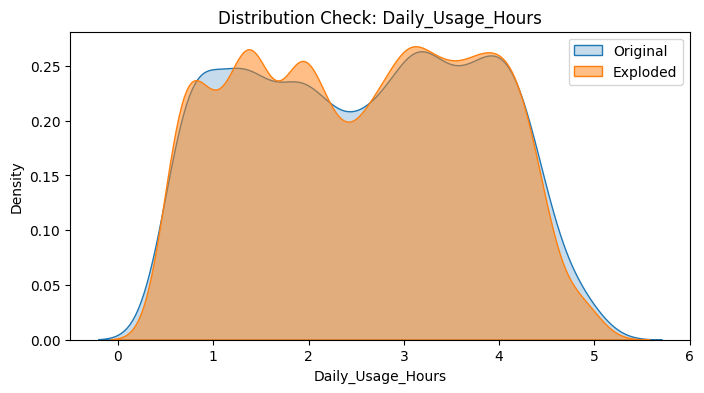

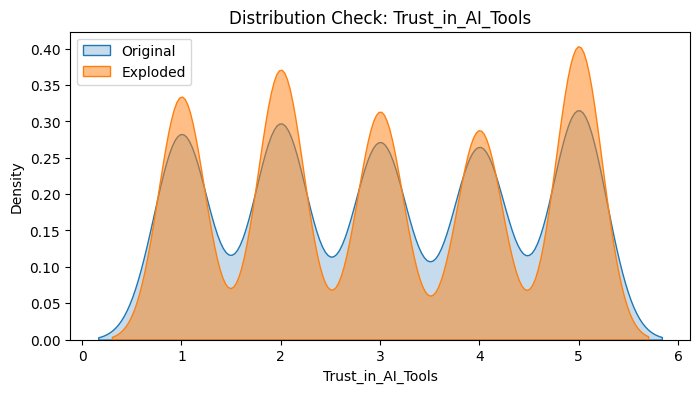

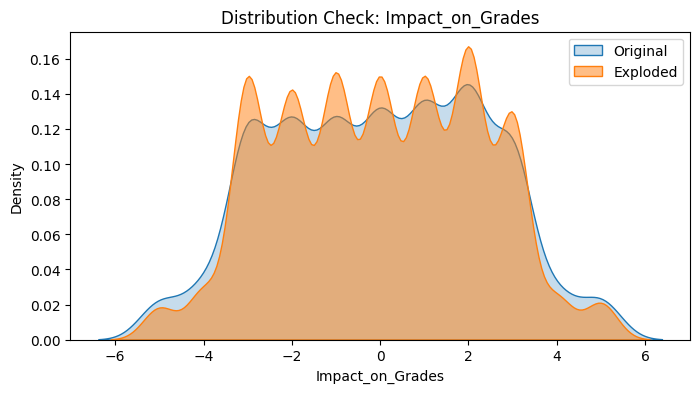

In [ ]:
# @title Visual Check

#@markdown Importing Libraries
import matplotlib.pyplot as plt
import seaborn as sns

#@markdown Making graph
for col in cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(df_vis[col], label='Original', fill=True)
    sns.kdeplot(df_vis_exploded[col], label='Exploded', fill=True, alpha=0.5)
    plt.title(f'Distribution Check: {col}')
    plt.legend()
    plt.show()

###Final Verdict
1. The mean, median, min, max of main numbers are almost same in original and exploded data.
2. The percentages of streams, year, and device used are very close (90-95%).
3. Graphs of original and exploded data look almost the same, showing patterns are kept.

##Thus Distribution is preserved

#**DATA VISUALIZATION**

In [ ]:
#@title Visualization Copies
print("Original Dataset")
display(df_vis.head(5))
print("\n\n\n")
print("Exploded Dataset")
display(df_vis_exploded.head(5))

Original Dataset


,Student_Name,College_Name,Stream,Year_of_Study,AI_Tools_Used,Daily_Usage_Hours,Use_Cases,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,State,Device_Used,Internet_Access
0,Aarav,Indian Institute of Information Technology,Engineering,4,Gemini,0.9,"Assignments, Coding Help",2,2,No,Copilot,9,Yes,Uttar pradesh,Mobile,Poor
1,Vivaan,"Government Ram Bhajan Rai NES College, Jashpur",Commerce,2,ChatGPT,3.4,Learning new topics,3,-3,Yes,Other,6,No,Chhattisgarh,Laptop,Poor
2,Aditya,Dolphin PG Institute of BioMedical & Natural,Science,2,Copilot,3.6,"MCQ Practice, Projects",5,0,No,Gemini,1,No,Uttarakhand,Tablet,Poor
3,Vihaan,Shaheed Rajguru College of Applied Sciences for,Arts,2,Copilot,2.9,Content Writing,5,2,Yes,Gemini,5,No,Delhi ncr,Laptop,High
4,Arjun,Roorkee College of Engineering,Science,1,Gemini,0.9,"Doubt Solving, Resume Writing",1,3,Yes,Other,8,Yes,Uttarakhand,Laptop,Medium






Exploded Dataset


,Stream,Year_of_Study,AI_Tools_Used,Daily_Usage_Hours,Use_Cases,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,Device_Used,Internet_Access
0,Engineering,4,Gemini,0.9,Assignments,2,2,No,Copilot,9,Yes,Mobile,Poor
1,Engineering,4,Gemini,0.9,Coding Help,2,2,No,Copilot,9,Yes,Mobile,Poor
2,Commerce,2,ChatGPT,3.4,Learning new topics,3,-3,Yes,Other,6,No,Laptop,Poor
3,Science,2,Copilot,3.6,MCQ Practice,5,0,No,Gemini,1,No,Tablet,Poor
4,Science,2,Copilot,3.6,Projects,5,0,No,Gemini,1,No,Tablet,Poor


In [ ]:
#@title Statistical Analysis
df_vis.describe()

,Year_of_Study,Daily_Usage_Hours,Trust_in_AI_Tools,Impact_on_Grades,Awareness_Level
count,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000
mean,2.472883,2.559685,3.023243,0.003320,5.828445
std,1.107912,1.213319,1.436934,2.370706,2.925481
min,1.000000,0.500000,1.000000,-5.000000,1.000000
25%,2.000000,1.500000,2.000000,-2.000000,3.000000
50%,2.000000,2.600000,3.000000,0.000000,6.000000
75%,3.000000,3.600000,4.000000,2.000000,8.000000
max,4.000000,5.000000,5.000000,5.000000,10.000000


### Statistical Analysis insights
1. Most students are in year 2 and 3.
2. They use AI about 0.5 to 5 hours per day, normal is 2.5 hours.
3. Students trust AI tools okay (1-5 scale), average 3.
4. AI changes grades sometimes, from -5 to +5, middle is 0, many no change.
5. Students know AI tools a bit, average 6/10.

In [ ]:
#@title Importing Libraries for Visualization
import matplotlib.pyplot as plt
import seaborn as sns

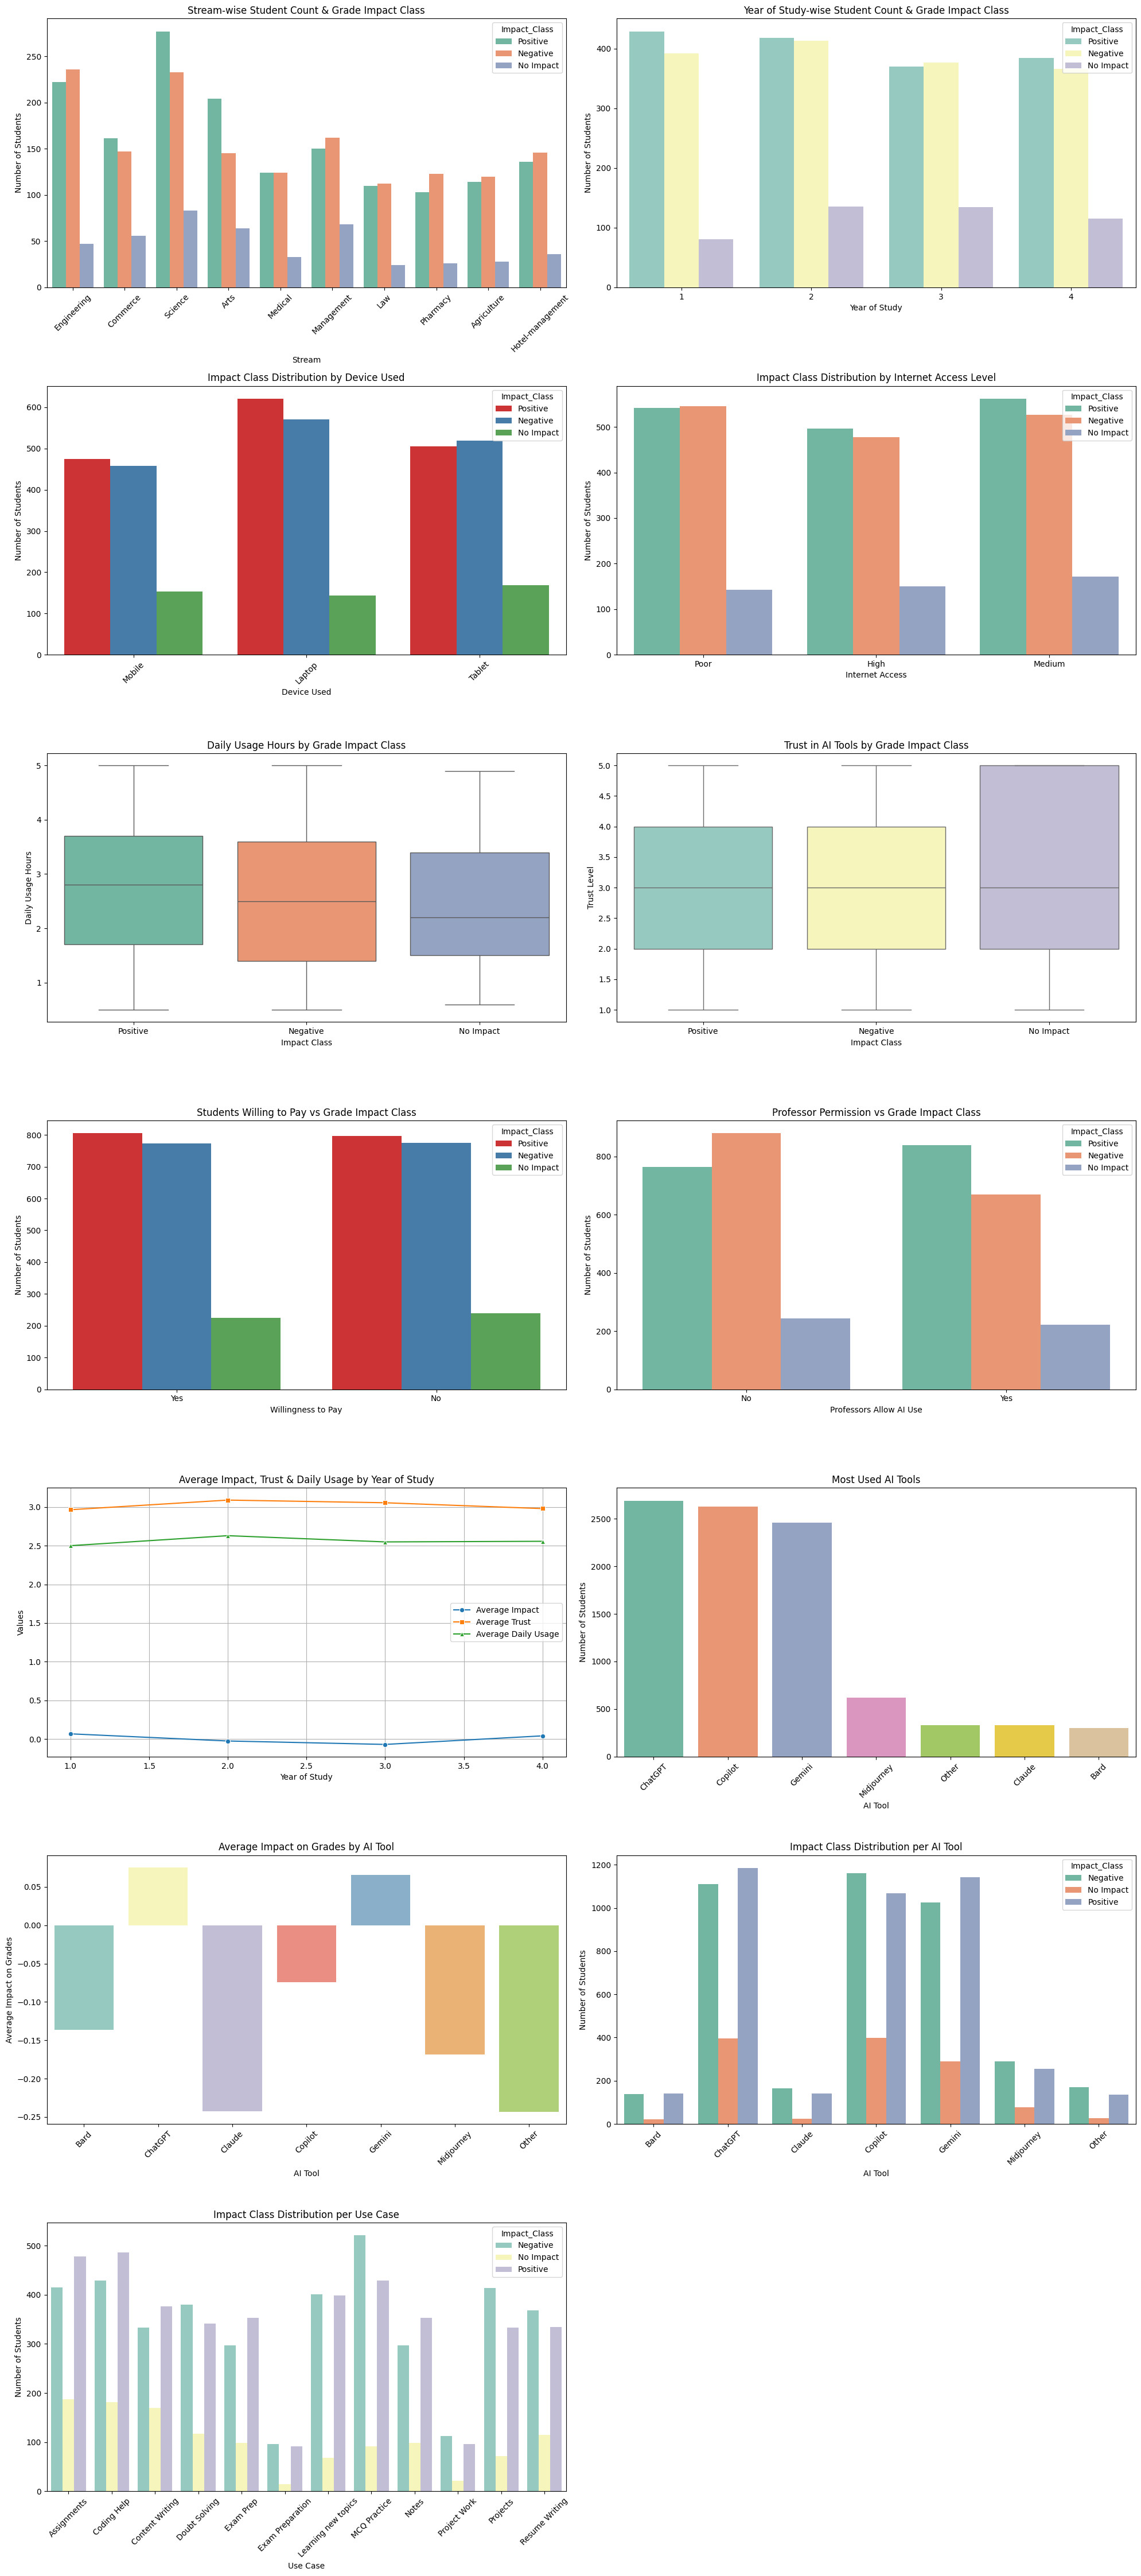

In [ ]:
#@title Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Defining Impact_class for visualization on both dataframes
df_vis['Impact_Class'] = df_vis['Impact_on_Grades'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'No Impact'))
df_vis_exploded['Impact_Class'] = df_vis_exploded['Impact_on_Grades'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'No Impact'))

# Creating a 7x2
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(20, 45))
axes = axes.flatten()

plot_index = 0

# Plot 1: Stream-wise Student Count & Grade Impact Class
sns.countplot(x='Stream', hue='Impact_Class', data=df_vis, palette='Set2', ax=axes[plot_index])
axes[plot_index].set_title('Stream-wise Student Count & Grade Impact Class')
axes[plot_index].set_xlabel('Stream')
axes[plot_index].set_ylabel('Number of Students')
axes[plot_index].tick_params(axis='x', rotation=45)
plot_index += 1

# Plot 2: Year of Study-wise Student Count & Grade Impact Class
sns.countplot(x='Year_of_Study', hue='Impact_Class', data=df_vis, palette='Set3', ax=axes[plot_index])
axes[plot_index].set_title('Year of Study-wise Student Count & Grade Impact Class')
axes[plot_index].set_xlabel('Year of Study')
axes[plot_index].set_ylabel('Number of Students')
plot_index += 1

# Plot 3: Impact Class Distribution by Device Used
sns.countplot(x='Device_Used', hue='Impact_Class', data=df_vis, palette='Set1', ax=axes[plot_index])
axes[plot_index].set_title('Impact Class Distribution by Device Used')
axes[plot_index].set_xlabel('Device Used')
axes[plot_index].set_ylabel('Number of Students')
axes[plot_index].tick_params(axis='x', rotation=45)
plot_index += 1

# Plot 4: Impact Class Distribution by Internet Access Level
sns.countplot(x='Internet_Access', hue='Impact_Class', data=df_vis, palette='Set2', ax=axes[plot_index])
axes[plot_index].set_title('Impact Class Distribution by Internet Access Level')
axes[plot_index].set_xlabel('Internet Access')
axes[plot_index].set_ylabel('Number of Students')
plot_index += 1

# Plot 5: Daily Usage Hours by Grade Impact Class
sns.boxplot(x='Impact_Class', y='Daily_Usage_Hours', data=df_vis, palette='Set2', ax=axes[plot_index], hue='Impact_Class', legend=False)
axes[plot_index].set_title('Daily Usage Hours by Grade Impact Class')
axes[plot_index].set_xlabel('Impact Class')
axes[plot_index].set_ylabel('Daily Usage Hours')
plot_index += 1

# Plot 6: Trust in AI Tools by Grade Impact Class
sns.boxplot(x='Impact_Class', y='Trust_in_AI_Tools', data=df_vis, palette='Set3', ax=axes[plot_index], hue='Impact_Class', legend=False)
axes[plot_index].set_title('Trust in AI Tools by Grade Impact Class')
axes[plot_index].set_xlabel('Impact Class')
axes[plot_index].set_ylabel('Trust Level')
plot_index += 1

# Plot 7: Students Willing to Pay vs Grade Impact Class
sns.countplot(x='Willing_to_Pay_for_Access', hue='Impact_Class', data=df_vis, palette='Set1', ax=axes[plot_index])
axes[plot_index].set_title('Students Willing to Pay vs Grade Impact Class')
axes[plot_index].set_xlabel('Willingness to Pay')
axes[plot_index].set_ylabel('Number of Students')
plot_index += 1

# Plot 8: Professor Permission vs Grade Impact Class
sns.countplot(x='Do_Professors_Allow_Use', hue='Impact_Class', data=df_vis, palette='Set2', ax=axes[plot_index])
axes[plot_index].set_title('Professor Permission vs Grade Impact Class')
axes[plot_index].set_xlabel('Professors Allow AI Use')
axes[plot_index].set_ylabel('Number of Students')
plot_index += 1

# Plot 9: Average Impact, Trust & Daily Usage by Year of Study
year_stats = df_vis.groupby('Year_of_Study')[['Impact_on_Grades','Trust_in_AI_Tools','Daily_Usage_Hours']].mean().reset_index()
sns.lineplot(x='Year_of_Study', y='Impact_on_Grades', marker='o', data=year_stats, label='Average Impact', ax=axes[plot_index])
sns.lineplot(x='Year_of_Study', y='Trust_in_AI_Tools', marker='s', data=year_stats, label='Average Trust', ax=axes[plot_index])
sns.lineplot(x='Year_of_Study', y='Daily_Usage_Hours', marker='^', data=year_stats, label='Average Daily Usage', ax=axes[plot_index])
axes[plot_index].set_title('Average Impact, Trust & Daily Usage by Year of Study')
axes[plot_index].set_xlabel('Year of Study')
axes[plot_index].set_ylabel('Values')
axes[plot_index].legend()
axes[plot_index].grid(True)
plot_index += 1

# Plot 10: Most Used AI Tools
ai_count = df_vis_exploded['AI_Tools_Used'].value_counts().reset_index(name='Count')
sns.barplot(x='AI_Tools_Used', y='Count', data=ai_count, palette='Set2', ax=axes[plot_index], hue='AI_Tools_Used', legend=False)
axes[plot_index].set_title('Most Used AI Tools')
axes[plot_index].set_xlabel('AI Tool')
axes[plot_index].set_ylabel('Number of Students')
axes[plot_index].tick_params(axis='x', rotation=45)
plot_index += 1

# Plot 11: Average Impact on Grades by AI Tool
ai_impact_avg = df_vis_exploded.groupby('AI_Tools_Used')['Impact_on_Grades'].mean().reset_index()
sns.barplot(x='AI_Tools_Used', y='Impact_on_Grades', data=ai_impact_avg, palette='Set3', ax=axes[plot_index], hue='AI_Tools_Used', legend=False)
axes[plot_index].set_title('Average Impact on Grades by AI Tool')
axes[plot_index].set_xlabel('AI Tool')
axes[plot_index].set_ylabel('Average Impact on Grades')
axes[plot_index].tick_params(axis='x', rotation=45)
plot_index += 1

# Plot 12: Impact Class Distribution per AI Tool
ai_impact_class = df_vis_exploded.groupby(['AI_Tools_Used','Impact_Class']).size().reset_index(name='Count')
sns.barplot(x='AI_Tools_Used', y='Count', hue='Impact_Class', data=ai_impact_class, palette='Set2', ax=axes[plot_index])
axes[plot_index].set_title('Impact Class Distribution per AI Tool')
axes[plot_index].set_xlabel('AI Tool')
axes[plot_index].set_ylabel('Number of Students')
axes[plot_index].tick_params(axis='x', rotation=45)
plot_index += 1

# Plot 13: Impact Class Distribution per Use Case )
usecase_impact = df_vis_exploded.groupby(['Use_Cases','Impact_Class']).size().reset_index(name='Count')
sns.barplot(x='Use_Cases', y='Count', hue='Impact_Class', data=usecase_impact, palette='Set3', ax=axes[plot_index])
axes[plot_index].set_title('Impact Class Distribution per Use Case')
axes[plot_index].set_xlabel('Use Case')
axes[plot_index].set_ylabel('Number of Students')
axes[plot_index].tick_params(axis='x', rotation=45)
plot_index += 1

# Remove any empty subplots
for i in range(plot_index, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Graphical Observations

Plot 1: Stream-wise Student Count & Grade Impact Class

1.  Engineering and Science streams have the highest student counts.
2.  Law, Pharmacy, Agriculture, and Hotel Management streams have significantly fewer students.

Plot 2: Year of Study-wise Student Count & Grade Impact Class

1.  Years 2 and 3 account for the majority of students.
2.  Years 1 and 4 have fewer students compared to intermediate years.

Plot 3: Impact Class Distribution by Device Used

1.  Laptops and Tablets are the most commonly used devices for AI tools.
2.  Mobile phone usage for AI tools is comparatively low.

Plot 4: Impact Class Distribution by Internet Access Level

1.  A large portion of students report 'High' internet access quality.
2.  'Poor' and 'Medium' internet access levels are less common and similar in number.

Plot 5: Daily Usage Hours by Grade Impact Class

1.  Daily AI usage hours vary widely across all impact classes.
2.  There isn't a distinct pattern of usage hours that clearly separates positive, negative, or no grade impact.

Plot 6: Trust in AI Tools by Grade Impact Class

1.  Most students exhibit moderate to high trust (levels 3-4) in AI tools.
2.  Very few students report extremely low (level 1) or extremely high (level 5) trust.

Plot 7: Students Willing to Pay vs Grade Impact Class

1.  More students are willing to pay for AI tool access than those who are not.

Plot 8: Professor Permission vs Grade Impact Class

1.  The distribution of grade impact (positive, negative, no impact) is roughly similar whether professors allow or disallow AI tool usage.

Plot 9: Average Impact, Trust & Daily Usage by Year of Study

1.  Average impact on grades hovers around zero across all years of study.
2.  Average trust and daily usage hours remain relatively consistent, around 3 and 2.5 hours respectively, throughout the years.

Plot 10: Most Used AI Tools

1.  ChatGPT, Copilot, and Gemini are the most frequently used AI tools.
2.  Bard, Claude, Midjourney, and Other tools are used less often.

Plot 11: Average Impact on Grades by AI Tool

1.  ChatGPT and Gemini show a slightly positive average impact on grades.
2.  Bard, Claude, Copilot, Midjourney, and Other tools show a slightly negative average impact.

Plot 12: Impact Class Distribution per AI Tool

1.  ChatGPT and Copilot have the largest counts for both positive and negative grade impacts, likely due to higher overall usage.
2.  The proportion of positive vs. negative impact varies by AI tool.

Plot 13: Impact Class Distribution per Use Case

1.  Use cases like 'Assignments', 'Coding Help', and 'Learning new topics' show higher student engagement.
2.  The balance between positive and negative grade impact differs significantly across various use cases.

#**Applying Model**

###1. KNN

In [ ]:
#@title Data Preparation for KNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df_cleaned.drop(['Impact_on_Grades', 'Impact_Category'], axis=1)
y = df_cleaned['Impact_on_Grades']

#@markdown Unconverted categorical features for OneHotEncoder
cat_cols = ['Stream', 'Device_Used']

#@markdown Numerical columns for standard scaler
num_cols = ['Year_of_Study', 'Daily_Usage_Hours', 'Trust_in_AI_Tools', 'Awareness_Level']

#@markdown Standardizing numerical values and encoding left categorical columns
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessing_data = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ],
    remainder='passthrough'
)

#@markdown Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#@markdown Shape of train and test sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (6104, 34)
Shape of X_test: (1527, 34)
Shape of y_train: (6104,)
Shape of y_test: (1527,)


### KNN-1

In [ ]:
#@title Applying KNN (Metric - Euclidean)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Pipeline and GridSearch
model = Pipeline([
    ('preprocessor', preprocessing_data),
    ('knn', KNeighborsClassifier())
])

grid = GridSearchCV(model, {'knn__n_neighbors': range(2, 31)}, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_['knn__n_neighbors'])
print("CV Accuracy:", round(grid.best_score_, 4))

#@markdown Predictions
y_train_pred = grid.predict(X_train)
y_test_pred = grid.predict(X_test)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Best K: 2
CV Accuracy: 0.7546


,Metric,Training,Testing
0,Accuracy,0.9569,0.8402
1,Precision,0.9584,0.8531
2,Recall,0.9569,0.8402
3,F1-Score,0.9564,0.8355


Euclidean metric was bad for high dimensions and binary data. Manhattan metric should work better.

Eculidean matric yielded a low test and validation accuracy since the data is high dimensional and binary data in most columns.

For such high dimensional data 'Manhattan' metric is considered more suitable

Here,
- The **ColumnTransformer** applies StandardScaler to numerical columns and OneHotEncoder to selected categorical columns.
- remainder='passthrough' ensures all other features, including those already encoded, are kept in the dataset for the model.

##KNN-2

In [ ]:
#@title Applying KNN (Metric - Manhattan)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Pipeline & GridSearch
model = Pipeline([
    ('preprocessor', preprocessing_data),
    ('knn', KNeighborsClassifier(metric = 'manhattan'))
])

#@markdown Define parameters for Grid Search
param_grid = {
    'knn__n_neighbors': range(2, 31),
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)


print("Best K:", grid.best_params_['knn__n_neighbors'])
print("CV Accuracy:", round(grid.best_score_, 4))

#@markdown Predictions
y_train_pred = grid.predict(X_train)
y_test_pred = grid.predict(X_test)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Best K: 2
CV Accuracy: 0.7762


,Metric,Training,Testing
0,Accuracy,0.9626,0.8585
1,Precision,0.9638,0.8656
2,Recall,0.9626,0.8585
3,F1-Score,0.9621,0.8534


Manhattan metric helped a bit but accuracy is still low. Data is too high-dimensional for plain KNN.

The model still has low test and validation accuracy pointing to very much high dimensional data for KNN to handle

The sudden drop in testing accuracy suggests a potentially overfitted model. This can be overcome by using PCA (Principal of Component Analysis).

**Principal of Component Analysis**

It transforms correlated variables into a smaller set of uncorrelated principal
components.

It's used for dimensionality reduction, simplifying data while retaining most variance, improving model efficiency and reducing overfitting.

###Applying PCA

## KNN-3

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 2)
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown Finding best K AFTER PCA
best_k = 0
best_score = 0

for k in range(2, 31):
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5)
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_k = k

print("Best K:", best_k)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')
knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 2
Best K: 2
CV Accuracy: 0.6894


,Metric,Training,Testing
0,Accuracy,0.9246,0.7479
1,Precision,0.9296,0.7621
2,Recall,0.9246,0.7479
3,F1-Score,0.9238,0.7421


PCA with 2 components didn't help much. We need to try more components to capture enough variance.

Even after applying PCA the train and validation accuracy are low , thus different values of n_components will be tried

## KNN-4

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 3)
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown Finding best K AFTER PCA
best_k = 0
best_score = 0

for k in range(2, 31):
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5)
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_k = k

print("Best K:", best_k)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')
knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 3
Best K: 2
CV Accuracy: 0.7547


,Metric,Training,Testing
0,Accuracy,0.9581,0.8284
1,Precision,0.9595,0.8362
2,Recall,0.9581,0.8284
3,F1-Score,0.9576,0.8227


More PCA components, but accuracy still pretty low. Maybe increasing K would help, let's see.

Still quiet low train and test accuracy thus , another value is tried

## KNN-5

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 4)
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown Finding best K AFTER PCA
best_k = 0
best_score = 0

for k in range(2, 31):
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5)
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_k = k

print("Best K:", best_k)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')
knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 4
Best K: 2
CV Accuracy: 0.7606


,Metric,Training,Testing
0,Accuracy,0.9594,0.8422
1,Precision,0.9609,0.8486
2,Recall,0.9594,0.8422
3,F1-Score,0.9589,0.8359


Accuracy is still not good. Even with 4 components, PCA isn't performing well. Need a different approach.

Another value of K

## KNN-6

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 0.95) 0.95 is 95% of the information is retained
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown Finding best K AFTER PCA
best_k = 0
best_score = 0

for k in range(2, 31):
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5)
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_k = k

print("Best K:", best_k)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')
knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 31
Best K: 2
CV Accuracy: 0.7682


,Metric,Training,Testing
0,Accuracy,0.9579,0.8487
1,Precision,0.9593,0.8599
2,Recall,0.9579,0.8487
3,F1-Score,0.9574,0.8443


Keeping 95% variance with PCA helps a bit, but accuracy is stagnant. The model might be overfitting at K=2.

The model is still having low accuracy , another value of k is tried

## KNN-7

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 0.90) 0.90 is 90% of the information is retained
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown  Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
}

grid = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

best_k = grid.best_params_['n_neighbors']
best_score = grid.best_score_

print("Best K:", best_k)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan'
)

knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 25
Best K: 2
CV Accuracy: 0.768


,Metric,Training,Testing
0,Accuracy,0.9577,0.8500
1,Precision,0.9590,0.8584
2,Recall,0.9577,0.8500
3,F1-Score,0.9572,0.8449


Even with 90% variance retained in PCA, accuracy is not improving. The model is still overfitting at K=2.

Still the model is overfitting

The model is still overfitting thus a new metric of weights will be used with value 'distance' is used.

weights = distance

About

In KNN, weights='distance' means closer neighbors influence the prediction more. It assigns higher importance to nearby data points, improving accuracy by reducing the impact of distant, less relevant neighbors.

KNN-8

In [ ]:
#@title Using weights = distance without PCA at k = 2
#@title Applying KNN (Metric - Manhattan)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Pipeline & GridSearch
model = Pipeline([
    ('preprocessor', preprocessing_data),
    ('knn', KNeighborsClassifier(metric = 'manhattan'))
])

#@markdown Define parameters for Grid Search
param_grid = {
    'knn__n_neighbors': range(2, 31),
     'knn__weights':['distance']
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)


print("Best K:", grid.best_params_['knn__n_neighbors'])
print("CV Accuracy:", round(grid.best_score_, 4))

#@markdown Predictions
y_train_pred = grid.predict(X_train)
y_test_pred = grid.predict(X_test)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Best K: 2
CV Accuracy: 0.8788


,Metric,Training,Testing
0,Accuracy,1.0,0.9221
1,Precision,1.0,0.9217
2,Recall,1.0,0.9221
3,F1-Score,1.0,0.9212


Now using weights = 'distance' with PCA

KNN - 9

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 0.90) 0.90 is 90% of the information is retained with weights = 'distance'
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown  Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['distance']
    }

grid = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

best_k = grid.best_params_['n_neighbors']
best_score = grid.best_score_

print("Best K:", best_k)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan'
)

knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 25
Best K: 2
CV Accuracy: 0.8711


,Metric,Training,Testing
0,Accuracy,0.9577,0.8500
1,Precision,0.9590,0.8584
2,Recall,0.9577,0.8500
3,F1-Score,0.9572,0.8449


The model is still overfitting , it may because of high number of features in ipmact on grades column , thus a small classification will be done to positive , negative and no impact.

positive(>0)

negative(<0)

no impact(=0)

In [ ]:
#@title Data Preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df_cleaned.drop(['Impact_on_Grades', 'Impact_Category'], axis=1)
y = df_cleaned['Impact_Category']

#@markdown Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

#@markdown Unconverted categorical features for OneHotEncoder
cat_cols = ['Stream', 'Device_Used']

#@markdown Numerical columns for standard scaler
num_cols = ['Year_of_Study', 'Daily_Usage_Hours', 'Trust_in_AI_Tools', 'Awareness_Level']

#@markdown Standardizing numerical values and encoding left categorical columns
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessing_data = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ],
    remainder='passthrough'
)

#@markdown Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#@markdown Shape of train and test sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (6104, 34)
Shape of X_test: (1527, 34)
Shape of y_train: (6104,)
Shape of y_test: (1527,)


KNN - 10

In [ ]:
#@title Applying KNN (Metric - Manhattan)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Pipeline & GridSearch
model = Pipeline([
    ('preprocessor', preprocessing_data),
    ('knn', KNeighborsClassifier(metric = 'manhattan'))
])

#@markdown Define parameters for Grid Search
param_grid = {
    'knn__n_neighbors': range(2, 31),
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)


print("Best K:", grid.best_params_['knn__n_neighbors'])
print("CV Accuracy:", round(grid.best_score_, 4))

#@markdown Predictions
y_train_pred = grid.predict(X_train)
y_test_pred = grid.predict(X_test)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Best K: 2
CV Accuracy: 0.8501


,Metric,Training,Testing
0,Accuracy,0.9749,0.9005
1,Precision,0.9759,0.9077
2,Recall,0.9749,0.9005
3,F1-Score,0.9749,0.9001


Converting Impact_on_Grades to categories improved CV accuracy. It's less granular, but helps with model generalization.

Using PCA with Impact_Category

KNN - 11

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 0.90) 0.90 is 90% of the information is retained
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown  Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
}

grid = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

best_k = grid.best_params_['n_neighbors']
best_score = grid.best_score_

print("Best K:", best_k)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan'
)

knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 25
Best K: 2
CV Accuracy: 0.8496


,Metric,Training,Testing
0,Accuracy,0.9725,0.8919
1,Precision,0.9735,0.8995
2,Recall,0.9725,0.8919
3,F1-Score,0.9725,0.8915


After categorizing and PCA, accuracy is better. Now let's try tuning the weights along with n_neighbors.

KNN - 12

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 0.90) with weights tuning
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown  Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

best_k = grid.best_params_['n_neighbors']
best_weights = grid.best_params_['weights']
best_score = grid.best_score_

print("Best K:", best_k)
print("Best Weights:", best_weights)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan',
    weights=best_weights
)

knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 25
Best K: 2
Best Weights: distance
CV Accuracy: 0.9178


,Metric,Training,Testing
0,Accuracy,1.0,0.9489
1,Precision,1.0,0.9490
2,Recall,1.0,0.9489
3,F1-Score,1.0,0.9489


Weight tuning helped push accuracy higher. Now we need to find the optimal number of PCA components.

KNN - 13

In [ ]:
#@title Applying PCA (Metric - Minkowski,n_component = 0.90) with weights tuning
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown  Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(metric='minkowski'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

best_k = grid.best_params_['n_neighbors']
best_weights = grid.best_params_['weights']
best_score = grid.best_score_

print("Best K:", best_k)
print("Best Weights:", best_weights)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',
    weights=best_weights
)

knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 25
Best K: 2
Best Weights: distance
CV Accuracy: 0.8971


,Metric,Training,Testing
0,Accuracy,1.0,0.9306
1,Precision,1.0,0.9308
2,Recall,1.0,0.9306
3,F1-Score,1.0,0.9306


Minkowski metric gave slightly lower accuracy than Manhattan. Sticking to Manhattan, let's find the best PCA components.

Finding Optimal n_components for PCA

In [ ]:
#@title Finding Optimal value of n_components
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

X_train_processed = preprocessing_data.fit_transform(X_train)

best_n_components = 0
best_cv_score = -1

for n in range(1, X_train_processed.shape[1] + 1):
    pca_temp = PCA(n_components=n)
    X_train_pca_temp = pca_temp.fit_transform(X_train_processed)

    knn_temp = KNeighborsClassifier(n_neighbors=2, metric='manhattan', weights='distance')
    scores_temp = cross_val_score(knn_temp, X_train_pca_temp, y_train, cv=5, scoring='accuracy')

    mean_score = scores_temp.mean()
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_n_components = n

print(f"Optimal n_components: {best_n_components}")
print(f"Best CV Accuracy with optimal n_components: {best_cv_score:.4f}")

Optimal n_components: 29
Best CV Accuracy with optimal n_components: 0.9192


KNN - 14

In [ ]:
#@title Applying PCA (Metric - Manhattan,n_component = 29) with weights tuning
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=29)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown  Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

best_k = grid.best_params_['n_neighbors']
best_weights = grid.best_params_['weights']
best_score = grid.best_score_

print("Best K:", best_k)
print("Best Weights:", best_weights)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan',
    weights=best_weights
)

knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 29
Best K: 2
Best Weights: distance
CV Accuracy: 0.9192


,Metric,Training,Testing
0,Accuracy,1.0,0.9476
1,Precision,1.0,0.9477
2,Recall,1.0,0.9476
3,F1-Score,1.0,0.9476


Optimal PCA components (29) gave good accuracy. Let's try combining this with feature selection next.

KNN - 15

In [ ]:
#@title Applying PCA (Metric - Minkwoski,n_component = 29) with weights tuning
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Preprocessing
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown PCA
pca = PCA(n_components=29)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("After PCA:", X_train_pca.shape[1])

#@markdown  Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(metric='minkowski'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

best_k = grid.best_params_['n_neighbors']
best_weights = grid.best_params_['weights']
best_score = grid.best_score_

print("Best K:", best_k)
print("Best Weights:", best_weights)
print("CV Accuracy:", round(best_score, 4))

#@markdown Final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',
    weights=best_weights
)

knn.fit(X_train_pca, y_train)

#@markdown Predictions
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

#@markdown Metrics
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    ]
})

display(metrics.round(4))

Original features: 45
After PCA: 29
Best K: 2
Best Weights: distance
CV Accuracy: 0.9063


,Metric,Training,Testing
0,Accuracy,1.0,0.9371
1,Precision,1.0,0.9376
2,Recall,1.0,0.9371
3,F1-Score,1.0,0.9372


Minkowski with optimal PCA components is still not beating Manhattan. Sticking with Manhattan and trying feature selection.

## Feature Selection

In [ ]:
#@title Performing Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

#@markdown Creating a SelectKBest instance with f_classif (for classification tasks)
k_features = X_train_processed.shape[1] // 2
selector = SelectKBest(f_classif, k=k_features)

#@markdown Fit on processed training data
selector.fit(X_train_processed, y_train)

#@markdown Get selected features (boolean mask)
selected_features_mask = selector.get_support()

#@markdown Creating a DataFrame to show feature scores and selection status
feature_scores = pd.DataFrame({
    'Feature Index': range(X_train_processed.shape[1]),
    'Score': selector.scores_,
    'P-value': selector.pvalues_,
    'Selected': selected_features_mask
})

print(f"Selected {k_features} features out of {X_train_processed.shape[1]} original features.")

#@markdown Transforming the training and testing data to include only selected features
X_train_selected = selector.transform(X_train_processed)
X_test_selected = selector.transform(X_test_processed)

print(f"Shape of X_train after feature selection: {X_train_selected.shape}")
print(f"Shape of X_test after feature selection: {X_test_selected.shape}")

Selected 22 features out of 45 original features.
Shape of X_train after feature selection: (6104, 22)
Shape of X_test after feature selection: (1527, 22)


KNN - 16

In [ ]:
#@title Applying KNN(metric = Manhattan,Feature Selection)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Finding best K AFTER Feature Selection using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_selected, y_train)

best_k_fs = grid.best_params_['n_neighbors']
best_weights_fs = grid.best_params_['weights']
best_score_fs = grid.best_score_

print("Best K:", best_k_fs)
print("Best Weights:", best_weights_fs)
print("CV Accuracy:", round(best_score_fs, 4))

#@markdown Final model
knn_fs = KNeighborsClassifier(
    n_neighbors=best_k_fs,
    metric='manhattan',
    weights=best_weights_fs
)

knn_fs.fit(X_train_selected, y_train)

#@markdown Predictions
y_train_pred_fs = knn_fs.predict(X_train_selected)
y_test_pred_fs = knn_fs.predict(X_test_selected)

#@markdown Metrics
metrics_fs = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train, y_train_pred_fs),
        precision_score(y_train, y_train_pred_fs, average='weighted', zero_division=0),
        recall_score(y_train, y_train_pred_fs, average='weighted', zero_division=0),
        f1_score(y_train, y_train_pred_fs, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred_fs),
        precision_score(y_test, y_test_pred_fs, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred_fs, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred_fs, average='weighted', zero_division=0)
    ]
})

display(metrics_fs.round(4))

Best K: 2
Best Weights: distance
CV Accuracy: 0.9217


,Metric,Training,Testing
0,Accuracy,0.9998,0.9515
1,Precision,0.9998,0.9516
2,Recall,0.9998,0.9515
3,F1-Score,0.9998,0.9516


Feature selection further boosted accuracy. Now, let's incorporate SMOTE to handle the class imbalance better.

### KNN with SMOTE

KNN - 17

In [ ]:
#@title Applying SMOTE and PCA (Metric - Manhattan, n_component = 29) with weights tuning
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#@markdown Preprocessing data (numerical scaling and categorical one-hot encoding)
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Shape of X_train before SMOTE: {X_train_processed.shape}")
print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Target distribution before SMOTE:\n{pd.Series(y_train).value_counts()}")
print(f"Target distribution after SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

#@markdown PCA on SMOTE-augmented training data
pca = PCA(n_components=29) # Using the optimal n_components found previously
X_train_pca_smote = pca.fit_transform(X_train_smote)
X_test_pca_smote = pca.transform(X_test_processed)

print("Original features after preprocessing:", X_train_processed.shape[1])
print("After PCA on SMOTE data:", X_train_pca_smote.shape[1])

#@markdown Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['uniform', 'distance']
}

grid_smote = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_smote.fit(X_train_pca_smote, y_train_smote)

best_k_smote = grid_smote.best_params_['n_neighbors']
best_weights_smote = grid_smote.best_params_['weights']
best_score_smote = grid_smote.best_score_

print("Best K (with SMOTE):", best_k_smote)
print("Best Weights (with SMOTE):", best_weights_smote)
print("CV Accuracy (with SMOTE):", round(best_score_smote, 4))

#@markdown Final model
knn_smote = KNeighborsClassifier(
    n_neighbors=best_k_smote,
    metric='manhattan',
    weights=best_weights_smote
)

knn_smote.fit(X_train_pca_smote, y_train_smote)

#@markdown Predictions
y_train_pred_smote = knn_smote.predict(X_train_pca_smote)
y_test_pred_smote = knn_smote.predict(X_test_pca_smote)

#@markdown Metrics
metrics_smote = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train_smote, y_train_pred_smote),
        precision_score(y_train_smote, y_train_pred_smote, average='weighted', zero_division=0),
        recall_score(y_train_smote, y_train_pred_smote, average='weighted', zero_division=0),
        f1_score(y_train_smote, y_train_pred_smote, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred_smote),
        precision_score(y_test, y_test_pred_smote, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred_smote, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred_smote, average='weighted', zero_division=0)
    ]
})

display(metrics_smote.round(4))

Shape of X_train before SMOTE: (6104, 45)
Shape of X_train after SMOTE: (8043, 45)
Target distribution before SMOTE:
0    2681
2    2612
1     811
Name: count, dtype: int64
Target distribution after SMOTE:
0    2681
2    2681
1    2681
Name: count, dtype: int64
Original features after preprocessing: 45
After PCA on SMOTE data: 29
Best K (with SMOTE): 2
Best Weights (with SMOTE): distance
CV Accuracy (with SMOTE): 0.9448


,Metric,Training,Testing
0,Accuracy,1.0,0.9489
1,Precision,1.0,0.9492
2,Recall,1.0,0.9489
3,F1-Score,1.0,0.9490


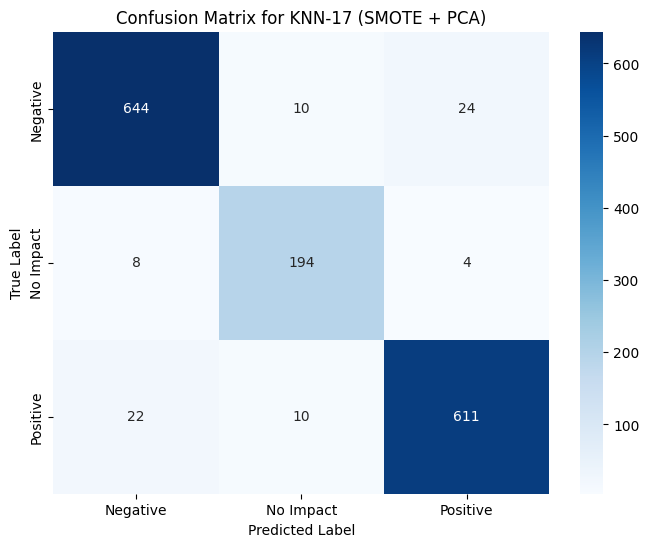

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#@title Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for KNN-17 (SMOTE + PCA)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
#@title Classification Report
print('Classification Report for KNN-17 (SMOTE + PCA):')
print(classification_report(y_test, y_test_pred_smote, target_names=le.classes_))

Classification Report for KNN-17 (SMOTE + PCA):
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.95       678
   No Impact       0.91      0.94      0.92       206
    Positive       0.96      0.95      0.95       643

    accuracy                           0.95      1527
   macro avg       0.94      0.95      0.94      1527
weighted avg       0.95      0.95      0.95      1527



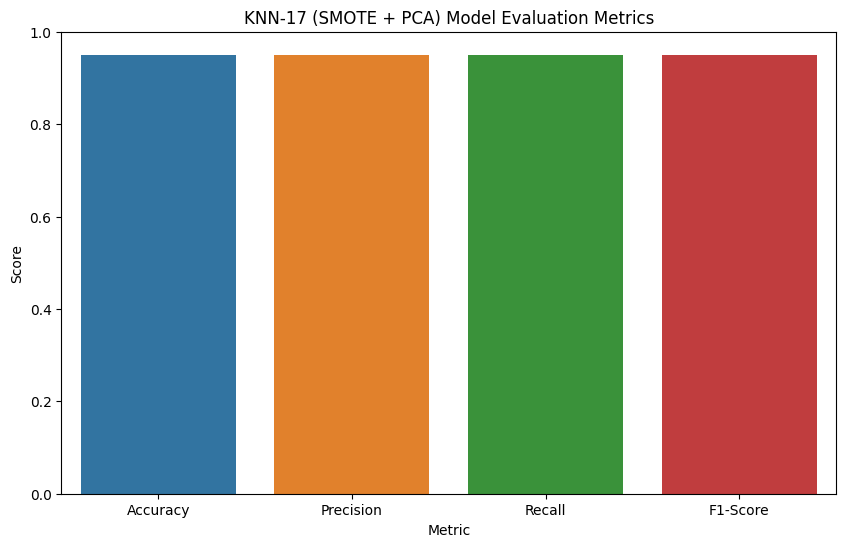

In [ ]:
#@title Bar Graph of Metrics for KNN-17
metrics_plot_df = metrics_smote.set_index('Metric')

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_plot_df.index, y='Testing', data=metrics_plot_df, hue=metrics_plot_df.index, legend=False)
plt.title('KNN-17 (SMOTE + PCA) Model Evaluation Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.show()

### Mean Squared Error for KNN-17

In [ ]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train_smote, y_train_pred_smote)
mse_test = mean_squared_error(y_test, y_test_pred_smote)

print(f"Mean Squared Error (Training): {mse_train:.4f}")
print(f"Mean Squared Error (Testing): {mse_test:.4f}")

Mean Squared Error (Training): 0.0000
Mean Squared Error (Testing): 0.1415


Next, we use feature selection with SMOTE and PCA to try and fix it.

### KNN - 18 (SMOTE + Feature Selection + PCA)

In [ ]:
#@title Applying SMOTE, Feature Selection and PCA (Metric - Manhattan, n_component = 29) with weights tuning
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

#@markdown Preprocessing data (numerical scaling and categorical one-hot encoding)
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Shape of X_train before SMOTE: {X_train_processed.shape}")
print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Target distribution before SMOTE:\n{pd.Series(y_train).value_counts()}")
print(f"Target distribution after SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

#@markdown Apply SelectKBest for feature selection on SMOTE-augmented training data
k_features_smote = X_train_smote.shape[1] // 2  # Use half of the features, or tune this value
selector_smote = SelectKBest(f_classif, k=k_features_smote)
X_train_selected_smote = selector_smote.fit_transform(X_train_smote, y_train_smote)
X_test_selected_smote = selector_smote.transform(X_test_processed)

print(f"Shape of X_train after SelectKBest: {X_train_selected_smote.shape}")
print(f"Shape of X_test after SelectKBest: {X_test_selected_smote.shape}")

#@markdown PCA on feature-selected, SMOTE-augmented training data
pca = PCA(n_components=k_features_smote) # Using the optimal n_components found previously, updated to k_features_smote
X_train_pca_smote_fs = pca.fit_transform(X_train_selected_smote)
X_test_pca_smote_fs = pca.transform(X_test_selected_smote)

print("Original features after preprocessing:", X_train_processed.shape[1])
print("After PCA on SMOTE and feature-selected data:", X_train_pca_smote_fs.shape[1])

#@markdown Finding best K AFTER PCA using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['uniform', 'distance']
}

grid_smote_fs_pca = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_smote_fs_pca.fit(X_train_pca_smote_fs, y_train_smote)

best_k_smote_fs_pca = grid_smote_fs_pca.best_params_['n_neighbors']
best_weights_smote_fs_pca = grid_smote_fs_pca.best_params_['weights']
best_score_smote_fs_pca = grid_smote_fs_pca.best_score_

print("Best K :", best_k_smote_fs_pca)
print("Best Weights :", best_weights_smote_fs_pca)
print("CV Accuracy :", round(best_score_smote_fs_pca, 4))

#@markdown Final model
knn_smote_fs_pca = KNeighborsClassifier(
    n_neighbors=best_k_smote_fs_pca,
    metric='manhattan',
    weights=best_weights_smote_fs_pca
)

knn_smote_fs_pca.fit(X_train_pca_smote_fs, y_train_smote)

#@markdown Predictions
y_train_pred_smote_fs_pca = knn_smote_fs_pca.predict(X_train_pca_smote_fs)
y_test_pred_smote_fs_pca = knn_smote_fs_pca.predict(X_test_pca_smote_fs)

#@markdown Metrics
metrics_smote_fs_pca = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train_smote, y_train_pred_smote_fs_pca),
        precision_score(y_train_smote, y_train_pred_smote_fs_pca, average='weighted', zero_division=0),
        recall_score(y_train_smote, y_train_pred_smote_fs_pca, average='weighted', zero_division=0),
        f1_score(y_train_smote, y_train_pred_smote_fs_pca, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred_smote_fs_pca),
        precision_score(y_test, y_test_pred_smote_fs_pca, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred_smote_fs_pca, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred_smote_fs_pca, average='weighted', zero_division=0)
    ]
})

display(metrics_smote_fs_pca.round(4))

Shape of X_train before SMOTE: (6104, 45)
Shape of X_train after SMOTE: (8043, 45)
Target distribution before SMOTE:
0    2681
2    2612
1     811
Name: count, dtype: int64
Target distribution after SMOTE:
0    2681
2    2681
1    2681
Name: count, dtype: int64
Shape of X_train after SelectKBest: (8043, 22)
Shape of X_test after SelectKBest: (1527, 22)
Original features after preprocessing: 45
After PCA on SMOTE and feature-selected data: 22
Best K : 2
Best Weights : distance
CV Accuracy : 0.9148


,Metric,Training,Testing
0,Accuracy,0.999,0.9005
1,Precision,0.999,0.9006
2,Recall,0.999,0.9005
3,F1-Score,0.999,0.9005


This model shows a very high training accuracy (0.9990), which indicates potential overfitting, even though the testing accuracy is around 0.9005.

KNN -  19

In [ ]:
#@title Applying SMOTE, PCA, and Feature Selection (Metric - Manhattan, n_component = 29) with weights tuning
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

#@markdown Preprocessing data (numerical scaling and categorical one-hot encoding)
X_train_processed = preprocessing_data.fit_transform(X_train)
X_test_processed = preprocessing_data.transform(X_test)

#@markdown Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Shape of X_train before SMOTE: {X_train_processed.shape}")
print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Target distribution before SMOTE:\n{pd.Series(y_train).value_counts()}")
print(f"Target distribution after SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

#@markdown PCA on SMOTE-augmented training data
pca = PCA(n_components=29) # Using the optimal n_components found previously
X_train_pca_smote = pca.fit_transform(X_train_smote)
X_test_pca_smote = pca.transform(X_test_processed)

print("\nOriginal features after preprocessing:", X_train_processed.shape[1])
print("After PCA on SMOTE data:", X_train_pca_smote.shape[1])

#@markdown Apply SelectKBest for feature selection on PCA-transformed, SMOTE-augmented training data
k_features_pca_fs = X_train_pca_smote.shape[1] // 2 # Taking half of the PCA components for feature selection
selector_pca_fs = SelectKBest(f_classif, k=k_features_pca_fs)
X_train_pca_fs_selected = selector_pca_fs.fit_transform(X_train_pca_smote, y_train_smote)
X_test_pca_fs_selected = selector_pca_fs.transform(X_test_pca_smote)

print(f"Shape of X_train after SelectKBest on PCA : {X_train_pca_fs_selected.shape}")
print(f"Shape of X_test after SelectKBest on PCA : {X_test_pca_fs_selected.shape}")

#@markdown Finding best K AFTER PCA and Feature Selection using GridSearch
param_grid = {
    'n_neighbors': range(2, 31),
    'weights': ['uniform', 'distance']
}

grid_smote_pca_fs = GridSearchCV(
    KNeighborsClassifier(metric='manhattan'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_smote_pca_fs.fit(X_train_pca_fs_selected, y_train_smote)

best_k_smote_pca_fs = grid_smote_pca_fs.best_params_['n_neighbors']
best_weights_smote_pca_fs = grid_smote_pca_fs.best_params_['weights']
best_score_smote_pca_fs = grid_smote_pca_fs.best_score_

print("\nBest K:", best_k_smote_pca_fs)
print("Best Weights:", best_weights_smote_pca_fs)
print("CV Accuracy:", round(best_score_smote_pca_fs, 4))

#@markdown Final model
knn_smote_pca_fs = KNeighborsClassifier(
    n_neighbors=best_k_smote_pca_fs,
    metric='manhattan',
    weights=best_weights_smote_pca_fs
)

knn_smote_pca_fs.fit(X_train_pca_fs_selected, y_train_smote)

#@markdown Predictions
y_train_pred_smote_pca_fs = knn_smote_pca_fs.predict(X_train_pca_fs_selected)
y_test_pred_smote_pca_fs = knn_smote_pca_fs.predict(X_test_pca_fs_selected)

#@markdown Metrics
metrics_smote_pca_fs = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training': [
        accuracy_score(y_train_smote, y_train_pred_smote_pca_fs),
        precision_score(y_train_smote, y_train_pred_smote_pca_fs, average='weighted', zero_division=0),
        recall_score(y_train_smote, y_train_pred_smote_pca_fs, average='weighted', zero_division=0),
        f1_score(y_train_smote, y_train_pred_smote_pca_fs, average='weighted', zero_division=0)
    ],
    'Testing': [
        accuracy_score(y_test, y_test_pred_smote_pca_fs),
        precision_score(y_test, y_test_pred_smote_pca_fs, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred_smote_pca_fs, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred_smote_pca_fs, average='weighted', zero_division=0)
    ]
})

display(metrics_smote_pca_fs.round(4))

Shape of X_train before SMOTE: (6104, 45)
Shape of X_train after SMOTE: (8043, 45)
Target distribution before SMOTE:
0    2681
2    2612
1     811
Name: count, dtype: int64
Target distribution after SMOTE:
0    2681
2    2681
1    2681
Name: count, dtype: int64

Original features after preprocessing: 45
After PCA on SMOTE data: 29
Shape of X_train after SelectKBest on PCA : (8043, 14)
Shape of X_test after SelectKBest on PCA : (1527, 14)

Best K: 2
Best Weights: distance
CV Accuracy: 0.9312


,Metric,Training,Testing
0,Accuracy,1.0,0.9384
1,Precision,1.0,0.9386
2,Recall,1.0,0.9384
3,F1-Score,1.0,0.9385
